In [76]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree
from xgboost import XGBClassifier, XGBRegressor


Text(0.5, 1.0, 'Weekly samples & defect ratio')

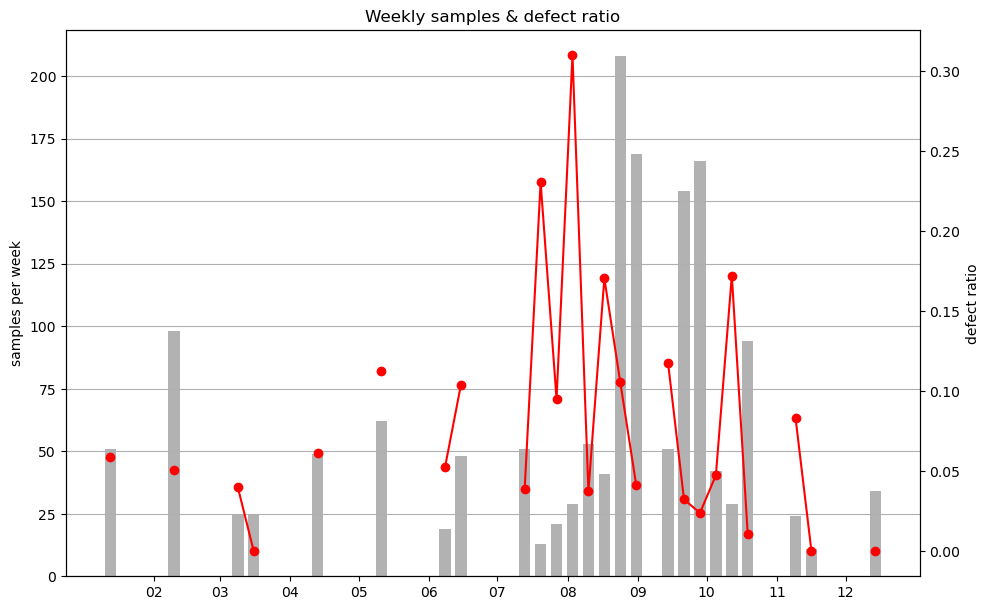

In [2]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系統找不到指定的檔案。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538

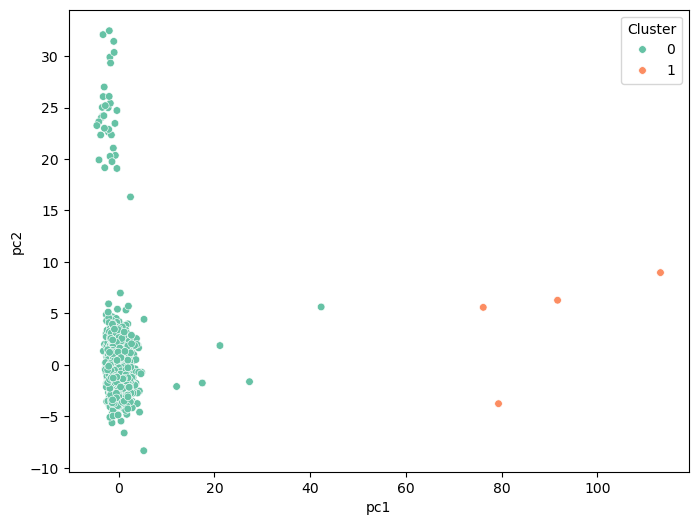

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 133 個主成分
cluster sizes: {0: 948, 1: 1197}
cluster    0    1
y                
0        743  687
1        205  510


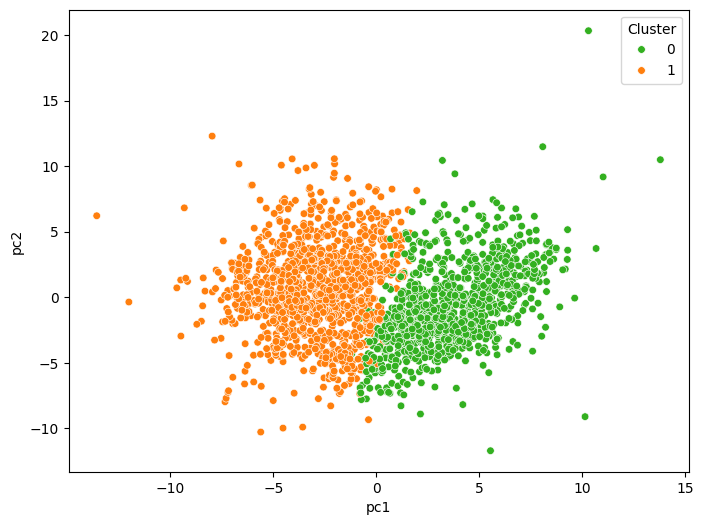

In [4]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette=palette)
plt.show()


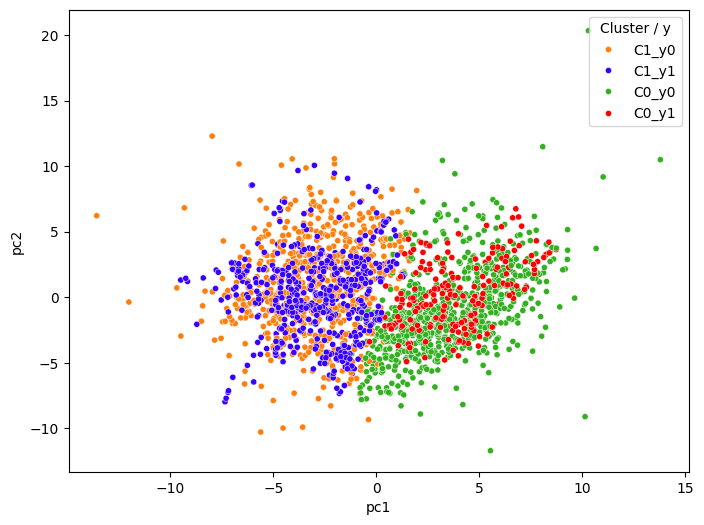

In [6]:
X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['Cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#33B020",  # cluster 0, y=0
    'C0_y1': "#ff0000",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#3700ff",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

In [6]:
# 1. 各群 y 分布
ct = pd.crosstab(df['y'], df['label'])
print(ct)

# 2. 各群中 y=1 的比例
p1 = ct.loc[1] / ct.sum(axis=0)
print('Pr(Y=1 | cluster):')
print(p1)

# 3. 分化程度 Δp 與 purity
delta_p = abs(p1.iloc[0] - p1.iloc[1])
purity = ct.max(axis=0) / ct.sum(axis=0)
print(f'Δp = {delta_p:.3f}')
print('purity by cluster:', purity.to_dict())

label    0    1
y              
0      743  687
1      205  510
Pr(Y=1 | cluster):
label
0    0.216245
1    0.426065
dtype: float64
Δp = 0.210
purity by cluster: {0: 0.7837552742616034, 1: 0.5739348370927319}


---
---

In [ ]:
def local_surrogate(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=1000,
    sigma=1,
    surrogate_type="linear",
    random_state=None,
    # NEW: cluster gating
    cluster_func=None,   # callable: cluster_func(X)-> {0,1} or array-like
    cluster0=None,       # if None and cluster_func is not None, infer from x0
    max_trials=50,       # max rounds of resampling to reach n_samples
    min_accept=0.8,      # at least accept this fraction; else raise
):
    """
    x0: 原始特徵空間中的設計點
    blackbox_model: 已訓練好的黑箱模型, 需有 predict_proba 或 predict
    scaler: 已 fit 好的標準化物件 (如 StandardScaler). 若 None 則不做 scaling
    n_samples: 在 x0 鄰域內要產生的設計點 M (最終用來fit surrogate的點)
    sigma: 在「標準化空間」中的擾動標準差
    surrogate_type: "linear" 或 "tree"
    cluster_func: 若提供，會做同群 gating，只保留與 x0 同群的擾動點
    cluster0: 指定 x0 的群標籤；若 None 則由 cluster_func(x0) 推得
    """

    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0).reshape(1, -1)
    if scaler is not None:
        x0_scaled = scaler.transform(x0)
    else:
        x0_scaled = x0.copy()

    n_features = x0_scaled.shape[1]

    # NEW: infer cluster0 if needed
    if cluster_func is not None and cluster0 is None:
        c0 = cluster_func(x0)
        # allow scalar / length-1 array
        cluster0 = int(np.asarray(c0).reshape(-1)[0])

    # 2) 在標準化空間中抽樣，必要時做同群 accept-reject
    Z_scaled_list = []
    trials = 0
    while len(Z_scaled_list) < n_samples and trials < max_trials:
        trials += 1

        # oversample to reduce resampling loops when acceptance is low
        remaining = n_samples - len(Z_scaled_list)
        draw_n = max(remaining, int(remaining * 1.5))

        eps = rng.normal(loc=0.0, scale=sigma, size=(draw_n, n_features))
        cand_scaled = x0_scaled + eps

        # 3) 還原回原始空間 (供 cluster_func 與黑箱使用)
        if scaler is not None:
            cand = scaler.inverse_transform(cand_scaled)
        else:
            cand = cand_scaled

        if cluster_func is None:
            accept = np.ones(draw_n, dtype=bool)
        else:
            cc = cluster_func(cand)
            cc = np.asarray(cc).reshape(-1)
            accept = (cc.astype(int) == int(cluster0))

        if np.any(accept):
            Z_scaled_list.append(cand_scaled[accept])

    if len(Z_scaled_list) == 0:
        raise RuntimeError("No accepted samples. Check sigma or cluster_func.")

    Z_scaled = np.vstack(Z_scaled_list)[:n_samples]

    # acceptance diagnostic
    accepted = Z_scaled.shape[0]
    if accepted < int(min_accept * n_samples):
        raise RuntimeError(
            f"Low acceptance: accepted {accepted}/{n_samples}. "
            "Decrease sigma or change sampling space / cluster definition."
        )

    # final Z in original space
    if scaler is not None:
        Z = scaler.inverse_transform(Z_scaled)
    else:
        Z = Z_scaled

    # 4) 黑箱 oracle
    if hasattr(blackbox_model, "predict_proba"):
        y_local = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y_local = blackbox_model.predict(Z)

    # 5) fit surrogate
    if surrogate_type == "linear":
        surrogate = LinearRegression()
    elif surrogate_type == "tree":
        surrogate = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, n_jobs=-1, random_state=random_state)
    elif surrogate_type == 'xgb':
        surrogate = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
    # "LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
    # "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    # "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42)
    # "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    else:
        raise ValueError("surrogate_type must be 'someone'")

    surrogate.fit(Z, y_local)

    # 6) local fit
    y_hat_local = surrogate.predict(Z)
    mse = mean_squared_error(y_local, y_hat_local)
    r2 = r2_score(y_local, y_hat_local)

    info = {
        "mse": mse,
        "r2": r2,
        "Z": Z,
        "y_blackbox": y_local,
        "y_surrogate": y_hat_local,
        # NEW: diagnostics
        "cluster0": cluster0,
        "trials": trials,
        "n_used": len(Z),
    }
    return surrogate, info

In [103]:
def local_surrogate(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=1000,
    sigma=0.5,
    surrogate_type=None,
    random_state=None,
):
    """
    x0: 1D array-like, 原始特徵空間中的設計點
    blackbox_model: 已訓練好的黑箱模型, 需有 predict_proba 或 predict
    scaler: 已 fit 好的標準化物件 (如 StandardScaler). 若 None 則不做 scaling
    n_samples: 在 x0 鄰域內要產生的設計點數 M
    sigma: 在「標準化空間」中的擾動標準差
    surrogate_type: "linear" (線性迴歸) 或 "tree" (決策樹迴歸)
    """
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0).reshape(1, -1)
    if scaler is not None:
        x0_scaled = scaler.transform(x0)
    else:
        x0_scaled = x0.copy()

    n_features = x0_scaled.shape[1]

    # 2) 在標準化空間中, 以 N(x0, sigma^2 I) 產生鄰域設計點 Z_scaled
    eps = rng.normal(loc=0.0, scale=sigma, size=(n_samples, n_features))
    Z_scaled = x0_scaled + eps

    # 3) 還原回原始空間 Z (給 surrogate 用的自變數)
    if scaler is not None:
        Z = scaler.inverse_transform(Z_scaled)
    else:
        Z = Z_scaled

    # 4) 用黑箱模型當 oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        # 二元分類, 取 class=1 機率當連續目標
        p = blackbox_model.predict_proba(Z)[:, 1]
        y_local = p
    else:
        # 沒有 predict_proba 就直接用 predict 的連續輸出
        y_local = blackbox_model.predict(Z)

    # 5) 在 (Z, y_local) 上 fit 一個簡單 surrogate
    if surrogate_type == "logistic":
        surrogate = LogisticRegression(max_iter=2000, class_weight="balanced", penalty="l1", solver="liblinear", random_state=42)

    elif surrogate_type == "tree":
        surrogate = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=random_state)

    elif surrogate_type == 'xgb':
        surrogate = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')

    else:
        raise ValueError("surrogate_type must be 'someone'")

    surrogate.fit(Z, y_local)

    # 6) 衡量 surrogate 對黑箱在鄰域的擬合程度
    y_hat_local = surrogate.predict(Z)
    mse = mean_squared_error(y_local, y_hat_local)
    r2 = r2_score(y_local, y_hat_local)

    info = {
        "mse": mse,
        "r2": r2,
        "Z": Z,                     # 鄰域設計點 (原始空間)
        "y_blackbox": y_local,      # 黑箱輸出
        "y_surrogate": y_hat_local  # surrogate 輸出
    }

    return surrogate, info


---
---

In [104]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)
# xgbc = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
logitR = LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42)
clf = logitR.fit(X_train, y_train)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

# 1) 找到最接近 0.5 的測試點
delta = np.abs(y_pred_prob - 0.5)
idx0 = int(np.argmin(delta))

# 2) 取該點作為 x0
x0 = X_test.iloc[idx0].values

print("chosen idx =", idx0)
print("p(x0) =", y_pred_prob[idx0])
print("|p-0.5| =", delta[idx0])

# 3) local surrogate
sur_model, info = local_surrogate(
    x0=x0,
    blackbox_model=clf,
    scaler=None,             # 目前空間已標準化
    n_samples=500,
    sigma=1,
    surrogate_type="xgb", # 或 "tree"
    random_state=42
)

print("local R2 =", info["r2"])
print("local MSE =", info["mse"])

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
chosen idx = 398
p(x0) = 0.5003528895295843
|p-0.5| = 0.0003528895295843437


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


local R2 = 0.9999523239964075
local MSE = 1.0097826281268135e-05


---
---

### 用logistic模型當 $\hat{\hat{g}}$

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warni

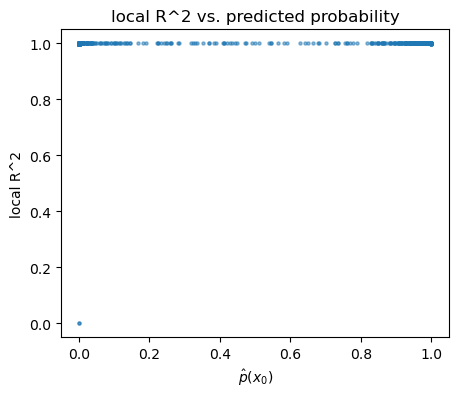

In [105]:
records = []

for i in range(X_test.shape[0]):
    x0 = X_test.iloc[i].values   # 設計點 x0，用標準化+SMOTE 後的空間

    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,
        n_samples=500,
        sigma=1,
        surrogate_type="xgb",
        random_state=42
    )
    
    records.append({'local_R2':info["r2"],
                    'local_MSE':info["mse"]})

local_df = pd.DataFrame(records)

idx = np.arange(len(X_test))
p_test = clf.predict_proba(X_test)[:, 1]

local_df["p_hat"] = p_test[idx]

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability")
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warni

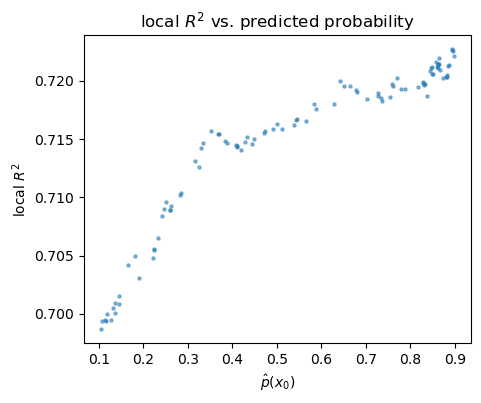

In [56]:
# 設定要取的 x0 個數
K = 100

# 取最接近 decision boundary 的 index
selected_idx = np.argsort(delta)[:K]

# （可選但一致性很重要）固定順序，避免之後對照混亂
selected_idx = np.sort(selected_idx)

records = []

for idx0 in selected_idx:   # selected_idx = 你挑的 p≈0.5 的 index
    x0 = X_test.iloc[idx0].values
    p0 = clf.predict_proba(X_test.iloc[[idx0]])[0, 1]

    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,
        n_samples=1000,
        sigma=1,
        surrogate_type="tree",
        random_state=42
    )

    records.append({
        "idx": idx0,
        "p_hat": p0,
        "local_R2": info["r2"],
        "local_MSE": info["mse"]
    })

local_df = pd.DataFrame(records)

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability")
plt.show()
